In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#Load Dataset
df = pd.read_csv("/content/drive/MyDrive/ML_Sem_IV/My_Project/dataset.csv")

#Data preprocessing
print("First five row of data:")
print(df.head())
print("\nColumns:",len(df.columns))
print("\nTotal_data:",len(df))
print("\nData_info:")
print(df.info())
print("\nShape:", df.shape)

#check null_value
print("\nCheck_nullvalue:\n")
print(df.isnull().sum())

#check duplicate_value
print("\nCheck_duplicatevalue:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("\nAgain_Check_duplicatevalue:", df.duplicated().sum())


#Encoding
le = LabelEncoder()
df['GENDER'] = le.fit_transform(df['GENDER'])
df['LUNG_CANCER'] = le.fit_transform(df['LUNG_CANCER'])
print("\nCheck Datatypes after Encode:\n")
print(df.dtypes)

#separation(Feature & Target)
print("\nSet the feature & traget columns:")
X = df.drop(["LUNG_CANCER"], axis=1)
y_class = df["LUNG_CANCER"]

#Scaling
print("\nScalling:\n")
print("Describe_Data\n",df.describe())
scaler = StandardScaler()
cols = ["AGE"]
X[cols] = scaler.fit_transform(X[cols])
print("\nDescribe data after scaling:")
print("\n",X.describe())


First five row of data:
  GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0      M   65        1               1        1              2   
1      F   55        1               2        2              1   
2      F   78        2               2        1              1   
3      M   60        2               1        1              1   
4      F   80        1               1        2              1   

   CHRONIC_DISEASE  FATIGUE  ALLERGY  WHEEZING  ALCOHOL_CONSUMING  COUGHING  \
0                2        1        2         2                  2         2   
1                1        2        2         2                  1         1   
2                1        2        1         2                  1         1   
3                2        1        2         1                  1         2   
4                1        2        1         2                  1         1   

   SHORTNESS_OF_BREATH  SWALLOWING_DIFFICULTY  CHEST_PAIN LUNG_CANCER  
0                    2          

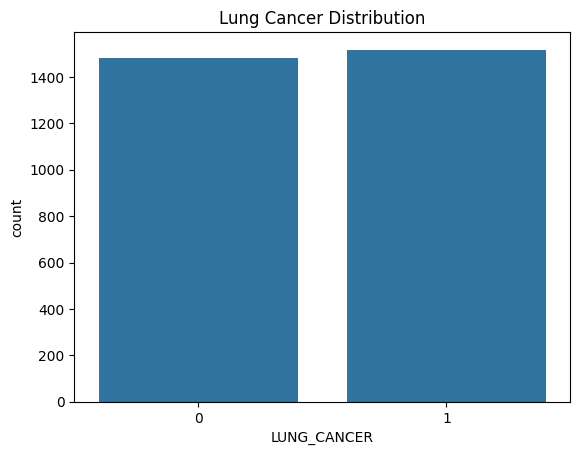

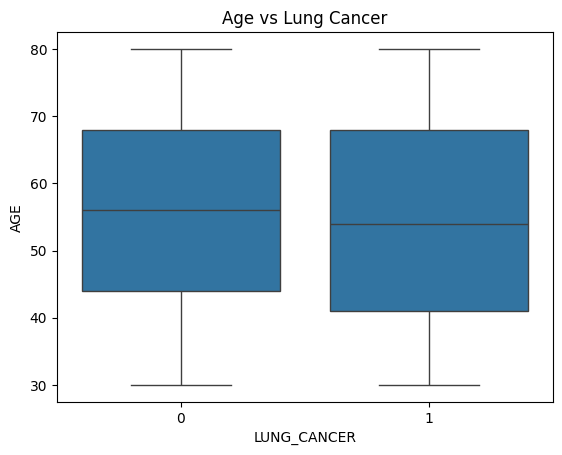

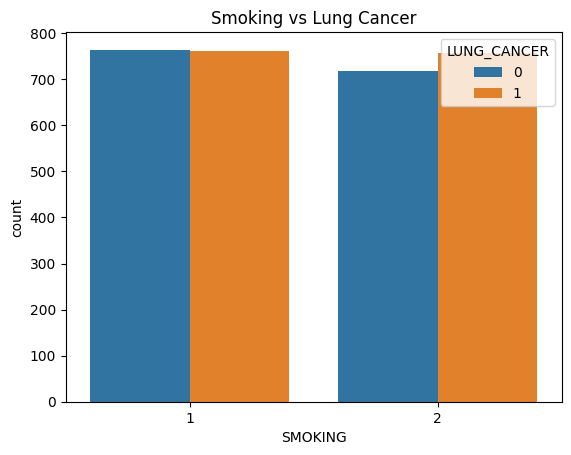

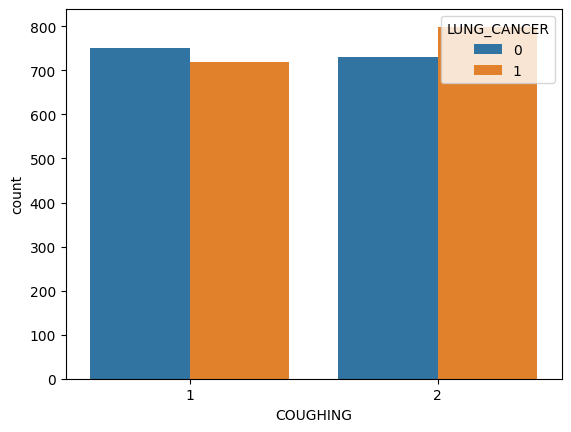

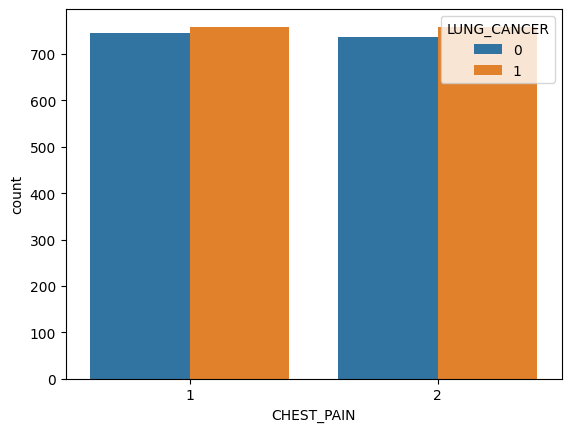

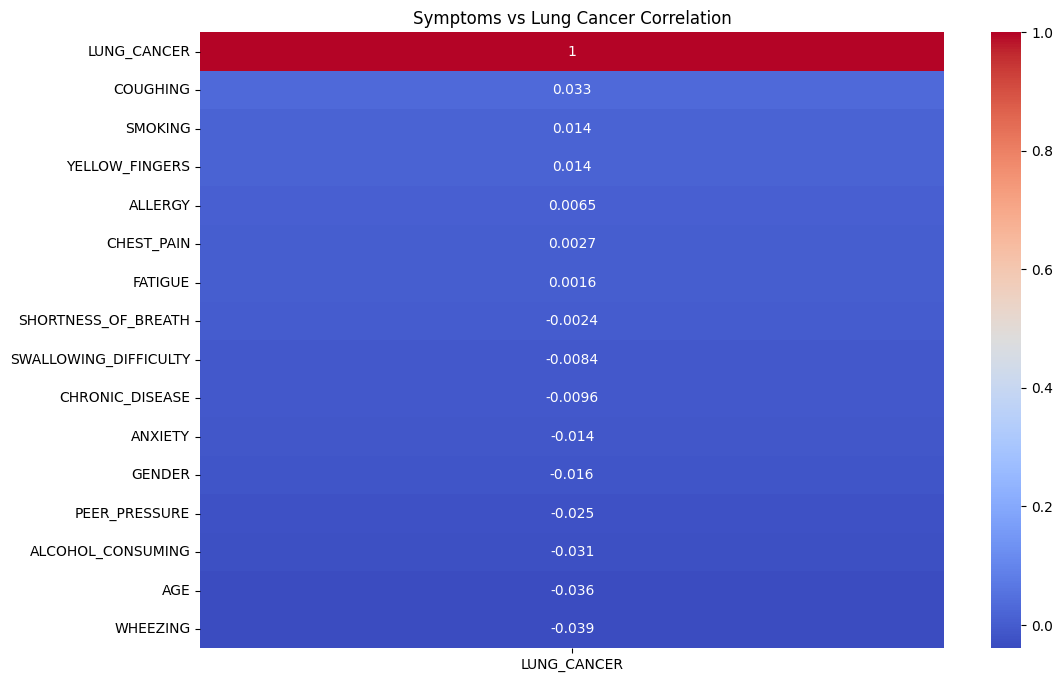

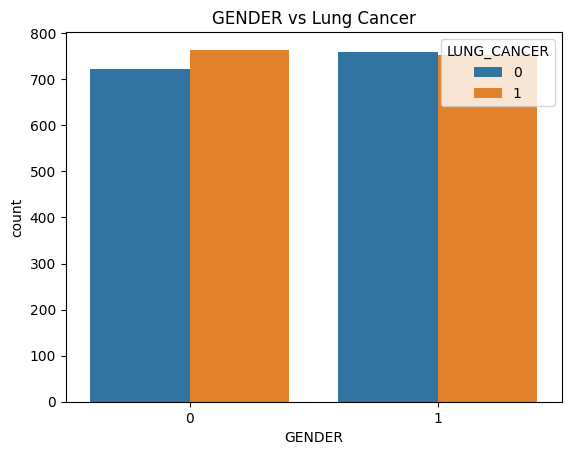

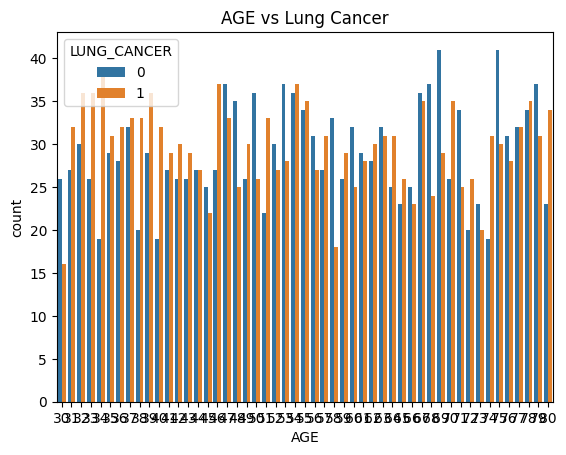

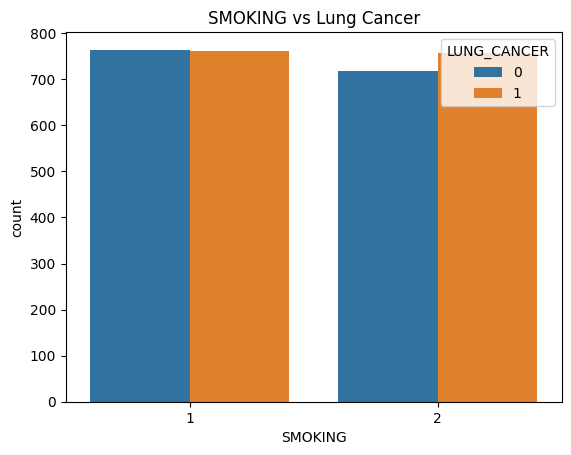

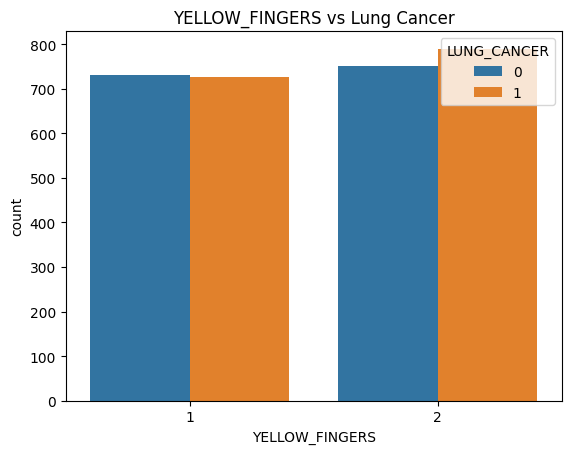

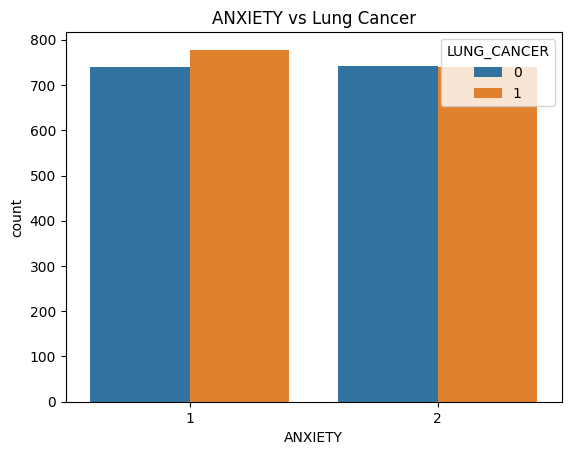

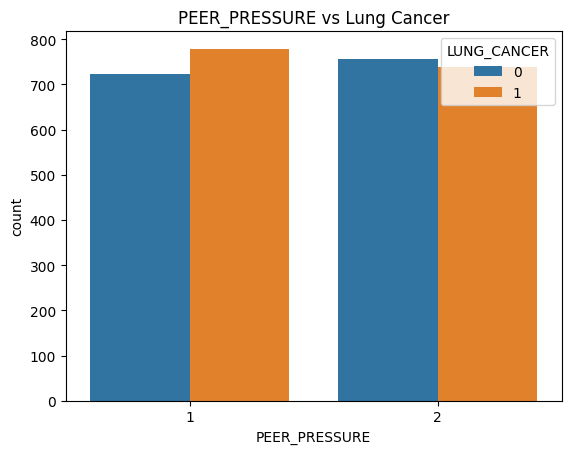

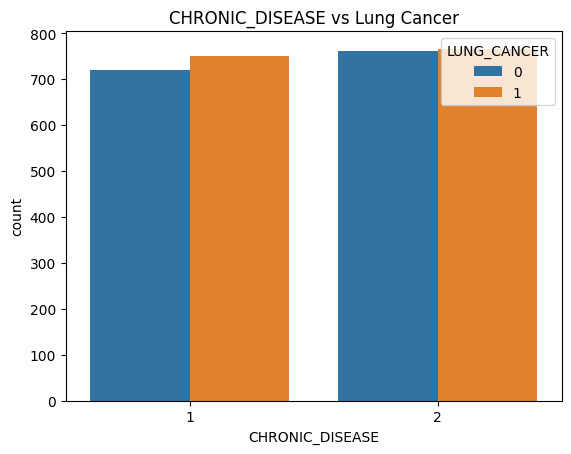

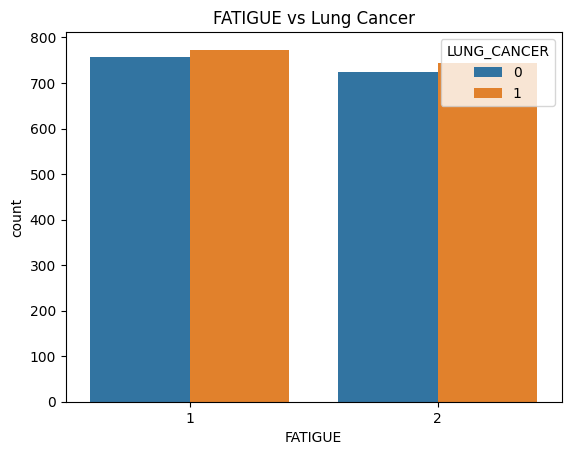

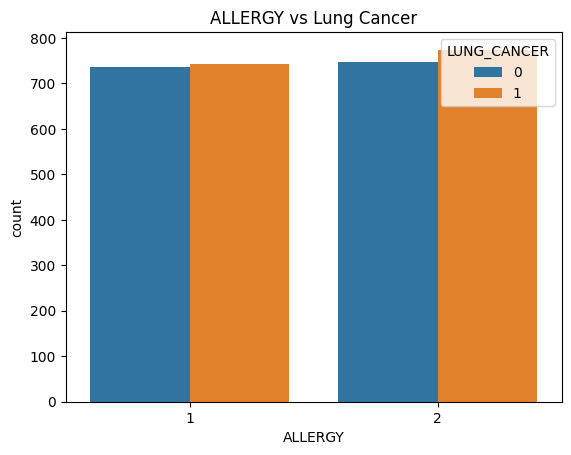

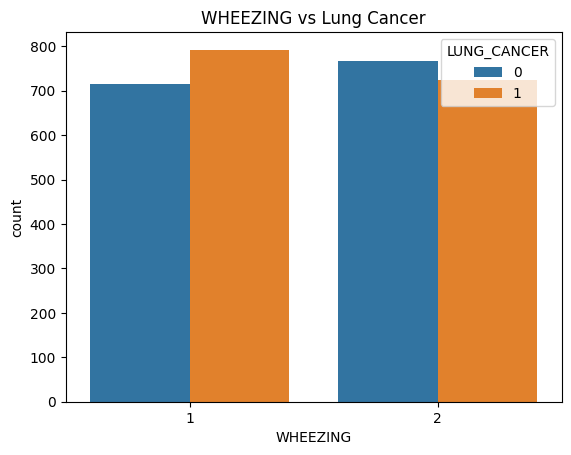

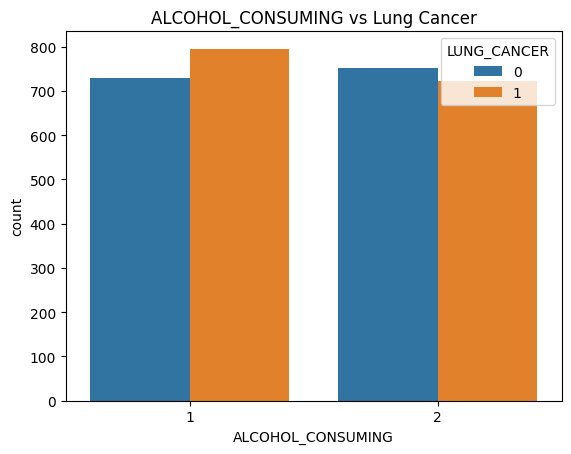

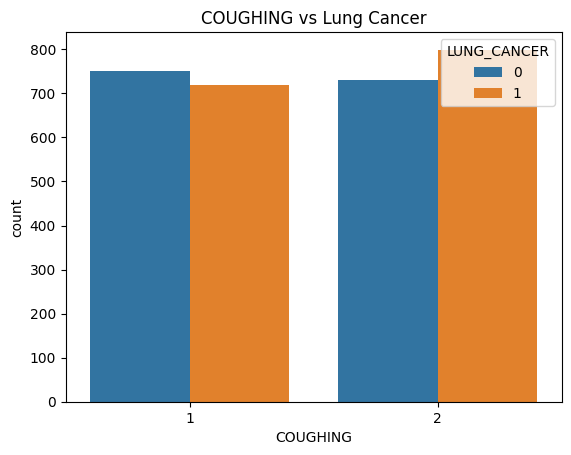

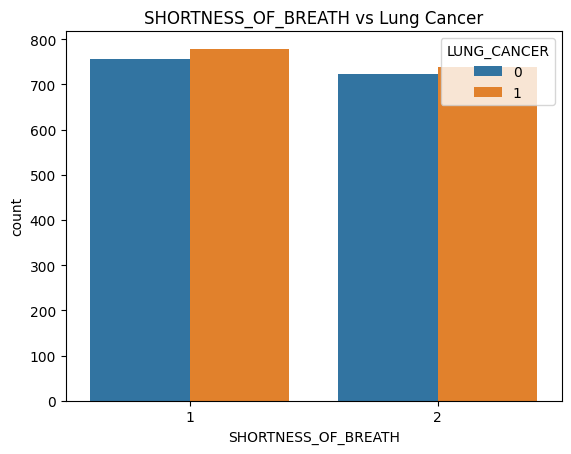

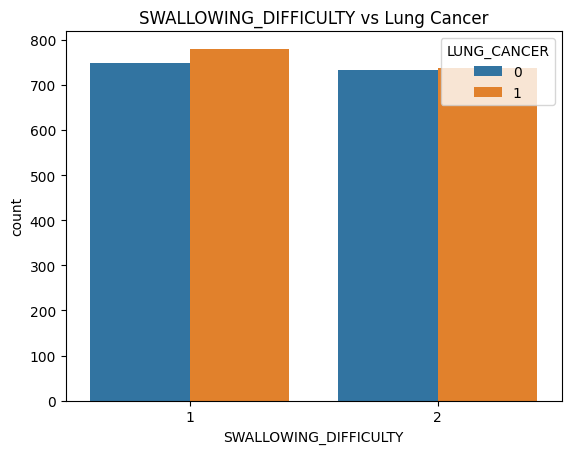

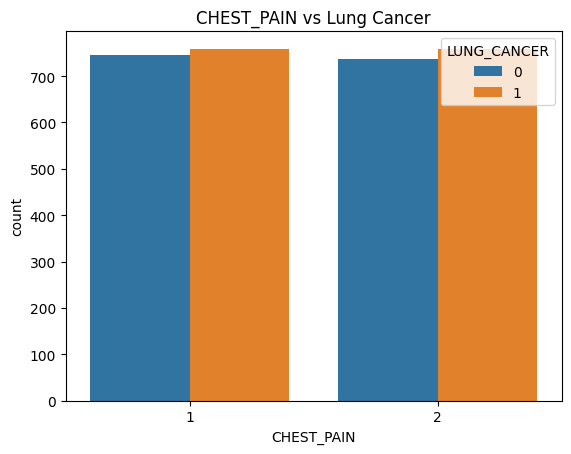

In [2]:
#visualization
sns.countplot(x='LUNG_CANCER', data=df)
plt.title("Lung Cancer Distribution")
plt.show()

sns.boxplot(x='LUNG_CANCER', y='AGE', data=df)
plt.title("Age vs Lung Cancer")
plt.show()

sns.countplot(x='SMOKING', hue='LUNG_CANCER', data=df)
plt.title("Smoking vs Lung Cancer")
plt.show()

sns.countplot(x='COUGHING', hue='LUNG_CANCER', data=df)
plt.show()

sns.countplot(x='CHEST_PAIN', hue='LUNG_CANCER', data=df)
plt.show()

plt.figure(figsize=(12,8))

# Correlation with target
corr = df.corr()

sns.heatmap(corr[['LUNG_CANCER']].sort_values(by='LUNG_CANCER', ascending=False),
            annot=True, cmap='coolwarm')

plt.title("Symptoms vs Lung Cancer Correlation")
plt.show()


symptoms = df.columns[:-1]  # last column = target

for col in symptoms:
    sns.countplot(x=col, hue='LUNG_CANCER', data=df)
    plt.title(f"{col} vs Lung Cancer")
    plt.show()



In [3]:
#Model training:
#Train_Test_Split
X_train, X_test, y_train, y_test = train_test_split(
X, y_class, test_size=0.2, random_state=42
)

#Logistic_regression
print("Logistic Regression:\n")
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
acc_log = accuracy_score(y_test, y_pred_log)
cm_log = confusion_matrix(y_test, y_pred_log)

#reduce threshold
y_prob = log_model.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.3).astype(int)
acc_new_log = accuracy_score(y_test, y_pred)
cm_new_log = confusion_matrix(y_test, y_pred)



#KNN CLASSIFICATION
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
cm_knn = confusion_matrix(y_test, y_pred_knn)

#Decision tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
cm_dt = confusion_matrix(y_test, y_pred_dt)

#random Forest
rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)




Logistic Regression:



In [4]:
#logistic Regression

print("Logistic Regression\n")
print("Accuracy:", acc_log)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
print("Accuracy:", acc_log)
print("\nLogistic Regression after reduce threshold:")
print("Accuracy:", acc_new_log)
print("\nConfusion Matrix:\n", cm_new_log)

#KNN Classification
print("\nKNN Classification\n")
print("Accuracy:", acc_knn)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

#Decison Tree
print("Decision Tree\n")
print("Accuracy:", acc_dt)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

#Random Forest
print("Random Forest\n")
print("Accuracy:", acc_rf)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Logistic Regression

Accuracy: 0.49666666666666665

Confusion Matrix:
 [[135 165]
 [137 163]]

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.45      0.47       300
           1       0.50      0.54      0.52       300

    accuracy                           0.50       600
   macro avg       0.50      0.50      0.50       600
weighted avg       0.50      0.50      0.50       600

Accuracy: 0.49666666666666665

Logistic Regression after reduce threshold:
Accuracy: 0.5

Confusion Matrix:
 [[  0 300]
 [  0 300]]

KNN Classification

Accuracy: 0.5333333333333333

Confusion Matrix:
 [[147 153]
 [127 173]]

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.49      0.51       300
           1       0.53      0.58      0.55       300

    accuracy                           0.53       600
   macro avg       0.53      0.53      0.53       600
weighted avg       0.53      0.5

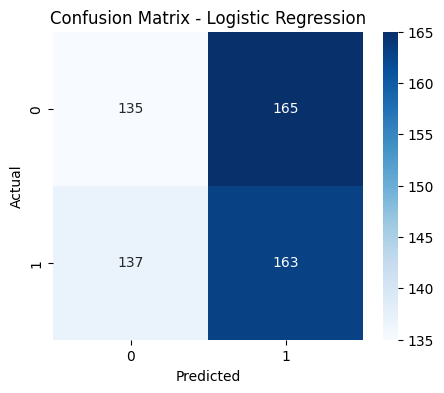

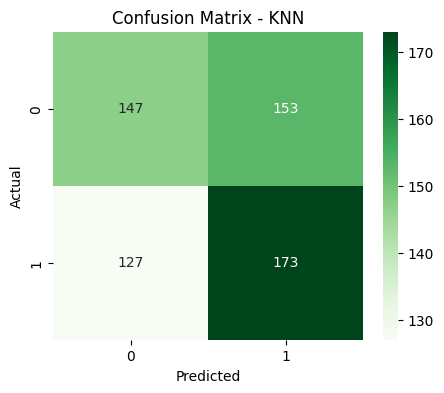

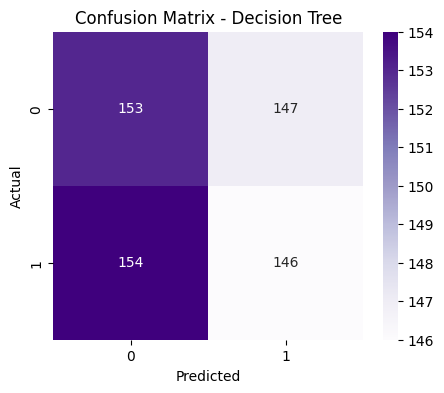

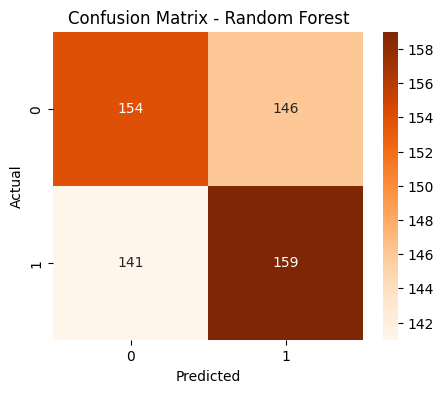

In [5]:
#Confusion Matrix ka Graph (Heatmap)
#Logistic Regression
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

#KNN Classification
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN")

plt.show()

#Decision Tree
cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

#random Forest
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

**13 may 2026**

last lab (deploye own project/model)

In [10]:
import joblib
joblib.dump(
    knn_model,
    "Cancer_pred.pkl"
)

['Cancer_pred.pkl']

In [11]:
from google.colab import files
files.download("Cancer_pred.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>